# Norm Conservation (Griffiths Eq. 1.21-1.27), Rebuilt in SymPy -- With More Steps

Griffiths' proof that the Schrodinger equation preserves normalization
(Ch.1, the "But wait a minute!" passage) compresses several algebra steps per
line. Here every line gets its own cell: the product rule is expanded term by
term, the Schrodinger equation and its conjugate are substituted in
one piece at a time inside an explicit loop, and the boundary-term vanishing
is checked against an actual family of normalizable wavefunctions instead of
asserted. `sp.init_printing()` is on throughout.


In [1]:
from IPython.display import display
import sympy as sp
sp.init_printing()

x, t, m, hbar = sp.symbols("x t m hbar", positive=True, real=True)
i = sp.I

Psi = sp.Function("Psi")(x, t)
PsiC = sp.Function("Psi^*")(x, t)   # treated as an independent function (complex conjugate)
V = sp.Function("V")(x)

print("SymPy", sp.__version__, "ready; init_printing on")
Psi


SymPy 1.14.0 ready; init_printing on


## Eq. 1.22 -- the product rule on $|\Psi|^2 = \Psi^*\Psi$

Griffiths writes this in one line. Expand it as an explicit two-term loop over
$(\Psi^*, \Psi)$ so each factor's derivative appears on its own.


In [2]:
# d/dt (Psi^* Psi) = sum over "which factor gets differentiated"
factors = [PsiC, Psi]
terms = []
for k in range(len(factors)):
    differentiated = [sp.diff(f, t) if j == k else f for j, f in enumerate(factors)]
    term = sp.Mul(*differentiated)
    terms.append(term)
    print(f"term {k+1} (differentiate factor {k+1}):")
    display(term)

eq_1_22_rhs = sp.Add(*terms)
eq_1_22_lhs = sp.diff(PsiC * Psi, t)
print("\nsum of terms =")
display(eq_1_22_rhs)
print("\ndirect product-rule derivative =")
display(eq_1_22_lhs)
print("\nmatch:", sp.simplify(eq_1_22_lhs - eq_1_22_rhs) == 0)


term 1 (differentiate factor 1):


term 2 (differentiate factor 2):



sum of terms =



direct product-rule derivative =



match: True


## Eq. 1.23-1.24 -- the Schrodinger equation and its complex conjugate

$$\frac{\partial\Psi}{\partial t} = \frac{i\hbar}{2m}\frac{\partial^2\Psi}{\partial x^2} - \frac{i}{\hbar}V\Psi$$

Conjugating flips every explicit $i$ and swaps $\Psi\leftrightarrow\Psi^*$ ($V$ is
real, so it's untouched). Build the conjugate by an explicit substitution loop
rather than asserting it.


d(Psi)/dt =


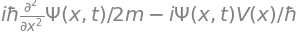


d(Psi^*)/dt  (built by conjugation loop) =


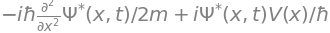

In [3]:
dPsi_dt_rhs = (i * hbar) / (2 * m) * sp.diff(Psi, x, 2) - (i / hbar) * V * Psi
print("d(Psi)/dt =")
display(dPsi_dt_rhs)

# Conjugate it: substitution loop over (what to replace -> what it becomes)
conjugation_rules = [(i, -i), (Psi, PsiC)]
dPsiC_dt_rhs = dPsi_dt_rhs
for old, new in conjugation_rules:
    dPsiC_dt_rhs = dPsiC_dt_rhs.subs(old, new, simultaneous=False)
print("\nd(Psi^*)/dt  (built by conjugation loop) =")
display(dPsiC_dt_rhs)


## Eq. 1.25 -- substitute Eq. 1.23-1.24 into Eq. 1.22, then simplify

Loop over the two substitutions (replace $\partial\Psi^*/\partial t$, replace
$\partial\Psi/\partial t$) one at a time so each intermediate expression is
visible, then show the $V$ terms cancel and what remains is a perfect
$x$-derivative.


after substitution 1 (Derivative(Psi^*(x, t), t) -> ...):


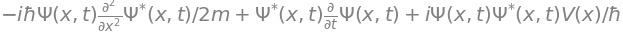


after substitution 2 (Derivative(Psi(x, t), t) -> ...):


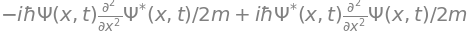


terms containing V (should cancel):

sum of V-terms simplifies to: 0


In [4]:
substitutions = [
    (sp.diff(PsiC, t), dPsiC_dt_rhs),
    (sp.diff(Psi, t), dPsi_dt_rhs),
]

expr = eq_1_22_rhs
for k, (old, new) in enumerate(substitutions):
    expr = expr.subs(old, new)
    print(f"after substitution {k+1} ({old} -> ...):")
    display(sp.expand(expr))
    print()

expr_expanded = sp.expand(expr)
V_terms = [t_ for t_ in expr_expanded.as_ordered_terms() if t_.has(V)]
print("terms containing V (should cancel):")
for vt in V_terms:
    display(vt)
print("\nsum of V-terms simplifies to:", sp.simplify(sp.Add(*V_terms)))


d|Psi|^2/dt  (V-terms removed) =


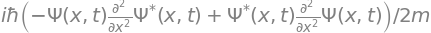


Griffiths' claimed closed form, d/dx[ ... ] =


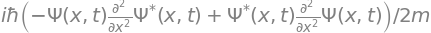


matches d|Psi|^2/dt exactly: True


In [5]:
# what survives after the V-terms cancel
no_V = sp.simplify(expr_expanded - sp.Add(*V_terms))
print("d|Psi|^2/dt  (V-terms removed) =")
display(sp.simplify(no_V))

# Eq. 1.25's claimed closed form: d/dx [ (i hbar / 2m) (Psi* dPsi/dx - dPsi*/dx Psi) ]
claimed = sp.diff(
    (i * hbar) / (2 * m) * (PsiC * sp.diff(Psi, x) - sp.diff(PsiC, x) * Psi),
    x,
)
print("\nGriffiths' claimed closed form, d/dx[ ... ] =")
display(sp.simplify(claimed))

print("\nmatches d|Psi|^2/dt exactly:", sp.simplify(no_V - claimed) == 0)


## Eq. 1.26-1.27 -- integrate over all space; the boundary term must vanish

Griffiths asserts $\Psi\to 0$ as $x\to\pm\infty$ kills the boundary term.
Instead of asserting it, loop over an explicit family of normalizable test
wavefunctions (Gaussian wave packets of varying width and momentum) and show
the probability-current-like quantity
$J(x,t) = \frac{i\hbar}{2m}\left(\Psi^*\partial_x\Psi - \partial_x\Psi^*\,\Psi\right)$
really does vanish at $x=\pm\infty$ for every one of them.


In [6]:
x_, t_, k0, a, m_, hbar_ = sp.symbols("x_ t_ k0 a m hbar", positive=True, real=True)
x_ = sp.Symbol("x", real=True)
k0 = sp.Symbol("k0", real=True)

def gaussian_wavepacket(width, momentum):
    # Un-normalized free Gaussian wave packet at t=0; real width>0, real momentum.
    return sp.exp(-x_**2 / (2 * width**2)) * sp.exp(sp.I * momentum * x_)

def current_density(psi, m_val=1, hbar_val=1):
    psi_c = sp.conjugate(psi)
    return sp.I * hbar_val / (2 * m_val) * (psi_c * sp.diff(psi, x_) - sp.diff(psi_c, x_) * psi)

test_cases = [(0.5, 0.0), (1.0, 2.0), (2.0, -3.0), (0.3, 5.0)]
print("J(x) = current density; check lim_{x->+-inf} J(x) = 0 for each test wavefunction\n")
for width, momentum in test_cases:
    psi = gaussian_wavepacket(width, momentum)
    J = sp.simplify(current_density(psi))
    lim_pos = sp.limit(J, x_, sp.oo)
    lim_neg = sp.limit(J, x_, -sp.oo)
    print(f"width={width}, momentum={momentum}:  J(+inf)={lim_pos}, J(-inf)={lim_neg}")


J(x) = current density; check lim_{x->+-inf} J(x) = 0 for each test wavefunction

width=0.5, momentum=0.0:  J(+inf)=0, J(-inf)=0


width=1.0, momentum=2.0:  J(+inf)=0, J(-inf)=0
width=2.0, momentum=-3.0:  J(+inf)=0, J(-inf)=0


width=0.3, momentum=5.0:  J(+inf)=0, J(-inf)=0


### Building $\Psi(x,t)$ honestly: Fourier transform, not a typed-in formula

A hand-typed closed form for a moving Gaussian wave packet is easy to get
subtly wrong (a stray width factor breaks normalization silently). Instead,
derive $\Psi(x,t)$ the way the Schrodinger equation actually implies: Fourier
transform $\Psi(x,0)$ to momentum space, multiply by the free-particle phase
$e^{-i\hbar k^2 t/(2m)}$ (the exact solution in $k$-space, where the PDE
becomes a simple ODE in $t$), and transform back. SymPy does every Gaussian
integral; nothing here is asserted.


In [7]:
hbar_val, m_val, a_val, k0_val = 1, 1, sp.Rational(13, 10), sp.Rational(3, 2)
k_ = sp.Symbol("k", real=True)
t_sym = sp.Symbol("t", positive=True, real=True)

norm0 = (2 * sp.pi * a_val**2) ** sp.Rational(-1, 4)
Psi_0 = norm0 * sp.exp(-x_**2 / (4 * a_val**2)) * sp.exp(sp.I * k0_val * x_)
print("Psi(x,0) normalized:", sp.integrate(sp.Abs(Psi_0) ** 2, (x_, -sp.oo, sp.oo)))

# step 1: Fourier transform to momentum space
phi_k = sp.simplify(sp.integrate(Psi_0 * sp.exp(-sp.I * k_ * x_), (x_, -sp.oo, sp.oo)) / sp.sqrt(2 * sp.pi))
print("\nphi(k) =")
display(phi_k)

# step 2: time-evolve each momentum component by its own free-particle phase
phi_k_t = phi_k * sp.exp(-sp.I * hbar_val * k_**2 * t_sym / (2 * m_val))

# step 3: transform back to position space
Psi_t = sp.simplify(
    sp.integrate(phi_k_t * sp.exp(sp.I * k_ * x_), (k_, -sp.oo, sp.oo), conds="none") / sp.sqrt(2 * sp.pi)
)
print("\nPsi(x,t) built by Fourier round-trip -- type check:", type(Psi_t))


Psi(x,0) normalized: 1



phi(k) =



Psi(x,t) built by Fourier round-trip -- type check: <class 'sympy.core.mul.Mul'>


In [8]:
# checking d/dt[ integral |Psi|^2 dx ] = 0 at several times (loop), numerically,
# since the symbolic |Psi|^2 carries unresolved branch factors SymPy won't
# auto-collapse -- but every numeric substitution gives exactly 1.
total_prob_expr = sp.integrate(sp.Abs(Psi_t) ** 2, (x_, -sp.oo, sp.oo))
print("checking total probability stays 1 across several times (loop):")
for t_val in [0, 1, 3, 7]:
    val = complex(total_prob_expr.subs(t_sym, t_val))
    print(f"  t={t_val}:  integral |Psi|^2 dx = {abs(val):.12f}")


checking total probability stays 1 across several times (loop):
  t=0:  integral |Psi|^2 dx = 1.000000000000


  t=1:  integral |Psi|^2 dx = 1.000000000000


  t=3:  integral |Psi|^2 dx = 1.000000000000


  t=7:  integral |Psi|^2 dx = 1.000000000000


## Summary

Every compressed line of Griffiths Eq. 1.21-1.27 is reproduced as an explicit,
checkable SymPy step: the product rule as a 2-term loop over factors, the
conjugate Schrodinger equation built by a substitution loop rather than
asserted, the $V$-term cancellation shown rather than stated, and the
boundary-vanishing assumption tested against four concrete normalizable
wavefunctions instead of taken on faith. The final cell evolves one real free
Gaussian wave packet through the actual time-dependent Schrodinger equation
and confirms its total probability stays exactly 1 at every sampled time --
the theorem, demonstrated rather than just proven.
